# 구위(Stuff) 모델 v2 — VAA·HAA 추가 / 루킹삼진 제외 / Waste 볼 점수 제외 (2025 정규시즌)

v1(`stuff_pipeline_260929.ipynb`) 대비 변경점

| 항목 | v1 | v2 |
|---|---|---|
| 3단계 설명변수 | 구속·무브먼트·릴리스·회전·팔각도·초기 속도/가속도 등 18개 + 구종·투구손 | v1 + **VAA·HAA** (홈플레이트 도달 진입각, 원값) |
| 3단계 학습 표본 | 인플레이 + 헛스윙(y=0) + **루킹삼진(y=0)** | 인플레이 + 헛스윙(y=0) — **루킹삼진 제외** |
| 4단계 점수 산정 | 모든 투구 | **볼 판정 + Savant Waste 존** 투구는 점수 없음 (NaN, 분포도엔 표시) |

- 1·2단계는 v1 과 동일 (`models/stage1_hit_rf.joblib`, 동일 seed 로 OOF 재계산)
- 산출물은 `models/v2/`, `outputs/v2/` 에 저장 — v1 산출물은 덮어쓰지 않음
- 마지막 섹션에서 v1 과 동일 split·동일 표본·동일 지표로 비교

In [1]:
import os, gc, warnings, joblib
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import log_loss, mean_squared_error, mean_absolute_error, r2_score

import stuff_pipeline as sp
import export_web_data as ew

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 110
os.makedirs(os.path.join('models', 'v2'), exist_ok=True)
os.makedirs(os.path.join('outputs', 'v2'), exist_ok=True)
SEED = sp.SEED
OUT = os.path.join('outputs', 'v2')

## 0. 데이터 로드 및 분할 (v1 과 동일)

In [2]:
df = sp.load_regular_season('games_25_final.pkl')
train_df, valid_df, valid_start = sp.split_last_month(df, months=1)
inner_start = valid_start - pd.Timedelta(days=14)
print(f'정규시즌 {len(df):,} / 학습 {len(train_df):,} / 검증 {len(valid_df):,} (검증 시작 {valid_start.date()}, 내부 홀드아웃 시작 {inner_start.date()})')

정규시즌 712,528 / 학습 588,716 / 검증 123,812 (검증 시작 2025-08-29, 내부 홀드아웃 시작 2025-08-15)


## 1·2. 타구결과 모델 → 타구질 score (v1 과 동일)
- 1단계 모델은 v1 에서 저장한 RandomForest(`max_depth=16, min_samples_leaf=25`)를 그대로 사용
- 학습셋 3단계 y 용 OOF 예측은 저장돼 있지 않으므로 v1 과 동일 설정·seed 로 재계산 → Gamma/Beta 모수가 v1 과 같은지 확인

In [3]:
hit_model = joblib.load(os.path.join('models', 'stage1_hit_rf.joblib'))
best_rf = {'max_depth': hit_model.max_depth, 'min_samples_leaf': hit_model.min_samples_leaf}
X1_tr, y1_tr = sp.build_hit_dataset(train_df)
X1_va, y1_va = sp.build_hit_dataset(valid_df)

P1_va = hit_model.predict_proba(X1_va)
P1_tr = cross_val_predict(
    RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED, **best_rf), X1_tr, y1_tr,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), method='predict_proba')
print('valid logloss :', round(log_loss(y1_va, P1_va), 4), '/ train OOF logloss :', round(log_loss(y1_tr, P1_tr), 4))

calib = sp.GammaBetaCalibrator().fit(sp.expected_value(P1_tr))
calib_v1 = joblib.load(os.path.join('models', 'stage2_gamma_beta.joblib'))
print('v2 :', calib)
print('v1 :', calib_v1)
hit_score = pd.concat([pd.Series(calib.transform(sp.expected_value(P1_tr)), index=X1_tr.index),
                       pd.Series(calib.transform(sp.expected_value(P1_va)), index=X1_va.index)])

valid logloss : 0.449 / train OOF logloss : 0.4581
v2 : GammaBetaCalibrator(gamma_a=0.657, gamma_scale=0.728, beta_a=0.423, beta_b=2.228)
v1 : GammaBetaCalibrator(gamma_a=0.657, gamma_scale=0.728, beta_a=0.423, beta_b=2.228)


## 3. 구위 모델 v2
### 3-1. VAA·HAA
홈플레이트 앞면(y = 17/12 ft) 도달 시점의 진입각을 초기 속도·가속도(y = 50 ft 기준)로 계산한다.

- `vy_f = −√(vy0² − 2·ay·(50 − 17/12))`, `t = (vy_f − vy0)/ay`, `vz_f = vz0 + az·t`, `vx_f = vx0 + ax·t`
- `VAA = −atan(vz_f / vy_f)`, `HAA = −atan(vx_f / vy_f)` (deg). 좌투는 수평 성분 반전 후 계산 → 우투 기준
- 원값을 그대로 사용 (사용자 결정). VAA 는 투구 높이(plate_z)와 상관이 커서 로케이션 정보가 일부 들어간다는 점은 해석 시 감안

In [4]:
feat = sp.add_stuff_features(df)
print(feat.groupby('pitch_type', observed=True)[['vaa', 'haa']].mean().round(2).T)
print('corr(VAA, plate_z) =', round(feat[['vaa', 'plate_z']].corr().iloc[0, 1], 3),
      '/ corr(HAA, plate_x·투구손 보정) =',
      round(np.corrcoef(feat['haa'].fillna(0), np.where(feat['p_throws'] == 'L', -1, 1) * feat['plate_x'].fillna(0))[0, 1], 3))

pitch_type    CH    CU     EP    FC    FF    FO    FS    KC    KN    SC    SI  \
vaa        -7.46 -9.72 -14.66 -6.12  -4.7 -8.89 -7.65 -9.49 -9.54 -7.26 -5.86   
haa         0.37  2.94   1.32   2.6  1.27  1.03  0.64  2.87  1.42  1.28  0.47   

pitch_type    SL    ST    SV  
vaa        -7.66 -7.71 -8.63  
haa         2.92  4.23  3.96  
corr(VAA, plate_z) = 0.754 / corr(HAA, plate_x·투구손 보정) = 0.663


### 3-2. 학습 표본 : 인플레이 + 헛스윙 (루킹삼진 제외)
split 은 v1 과 동일 : 학습 ~ 내부 홀드아웃 직전 / 내부 홀드아웃(학습셋 마지막 2주, 튜닝·early stopping) / 검증(마지막 1개월)

In [5]:
def split3(X, y):
    is_va = feat.loc[X.index, 'game_date'] >= valid_start
    is_es = (feat.loc[X.index, 'game_date'] >= inner_start) & ~is_va
    return (X[~is_va & ~is_es], y[~is_va & ~is_es]), (X[is_es], y[is_es]), (X[is_va], y[is_va])

X3, y3 = sp.build_stuff_dataset(feat, hit_score, features=sp.STUFF_FEATURES_V2, include_looking_k=False)
(X3_tr, y3_tr), (X3_es, y3_es), (X3_va, y3_va) = split3(X3, y3)

# v1 표본 (재현 확인 / 비교용)
X3v1, y3v1 = sp.build_stuff_dataset(feat, hit_score)
(_, _), (_, _), (X3v1_va, y3v1_va) = split3(X3v1, y3v1)

print('v2  train', X3_tr.shape, ' holdout', X3_es.shape, ' valid', X3_va.shape, ' y=0 비율', round((y3 == 0).mean(), 4))
print('v1  전체', X3v1.shape, ' valid', X3v1_va.shape, ' y=0 비율', round((y3v1 == 0).mean(), 4))
print('제외된 루킹삼진 :', len(X3v1) - len(X3))

v2  train (151051, 22)  holdout (15845, 22)  valid (35291, 22)  y=0 비율 0.3861
v1  전체 (211540, 20)  valid (36927, 20)  y=0 비율 0.4132
제외된 루킹삼진 : 9353


In [6]:
stuff_model = sp.fit_stuff_model(X3_tr, y3_tr, X3_es, y3_es, n_iter=12)
display(stuff_model.tuning_results_.head())

[01] rmse=0.16310 iter=601 {'num_leaves': 15, 'min_child_samples': 400, 'learning_rate': 0.05, 'colsample_bytree': 0.8, 'subsample': 0.7, 'reg_lambda': 5.0}
[02] rmse=0.16314 iter=2571 {'num_leaves': 15, 'min_child_samples': 200, 'learning_rate': 0.02, 'colsample_bytree': 0.6, 'subsample': 0.9, 'reg_lambda': 5.0}
[03] rmse=0.16308 iter=236 {'num_leaves': 63, 'min_child_samples': 400, 'learning_rate': 0.05, 'colsample_bytree': 1.0, 'subsample': 0.9, 'reg_lambda': 0.0}
[04] rmse=0.16322 iter=157 {'num_leaves': 127, 'min_child_samples': 100, 'learning_rate': 0.05, 'colsample_bytree': 0.8, 'subsample': 0.7, 'reg_lambda': 5.0}
[05] rmse=0.16310 iter=322 {'num_leaves': 127, 'min_child_samples': 200, 'learning_rate': 0.02, 'colsample_bytree': 1.0, 'subsample': 0.9, 'reg_lambda': 1.0}
[06] rmse=0.16310 iter=1446 {'num_leaves': 31, 'min_child_samples': 50, 'learning_rate': 0.02, 'colsample_bytree': 0.8, 'subsample': 0.9, 'reg_lambda': 0.0}
[07] rmse=0.16304 iter=394 {'num_leaves': 127, 'min_chi

,rmse,best_iter,num_leaves,min_child_samples,learning_rate,colsample_bytree,subsample,reg_lambda
10,0.163009,377,127,200,0.02,1.0,0.7,0.0
8,0.163018,310,63,400,0.05,0.6,0.7,1.0
6,0.163038,394,127,400,0.02,0.8,0.7,5.0
7,0.163067,698,63,100,0.02,1.0,0.7,5.0
9,0.163070,716,31,50,0.05,0.6,0.9,5.0


### 3-3. 검증셋 평가 — v1 과 동일 표본 비교
- **공통 표본 = v2 검증 표본(인플레이 + 헛스윙)** : 두 모델 모두 같은 y 로 평가
- 참고로 v1 표본(루킹삼진 포함)에서의 v1 성능(기존 RMSE 0.16093 재현 확인)도 함께 표기

In [7]:
model_v1 = joblib.load(os.path.join('models', 'stage3_stuff_lgbm.joblib'))
scaler_v1 = joblib.load(os.path.join('models', 'stage4_stuff_scaler.joblib'))

def reg_metrics(y, p):
    return {'RMSE': np.sqrt(mean_squared_error(y, p)), 'MAE': mean_absolute_error(y, p), 'R2': r2_score(y, p)}

pred_v2_va = stuff_model.predict(X3_va)
pred_v1_va = model_v1.predict(X3_va[sp.STUFF_FEATURES])
metrics3 = pd.DataFrame({
    '평균 baseline (공통 표본)': reg_metrics(y3_va, np.full(len(y3_va), pd.concat([y3_tr, y3_es]).mean())),
    'v1 LGBM (공통 표본)': reg_metrics(y3_va, pred_v1_va),
    'v2 LGBM (공통 표본)': reg_metrics(y3_va, pred_v2_va),
    'v1 LGBM (v1 표본, 참고)': reg_metrics(y3v1_va, model_v1.predict(X3v1_va)),
}).T
display(metrics3.round(5))

dec = pd.DataFrame({'v1': pred_v1_va, 'v2': pred_v2_va, 'actual': y3_va.values})
display(pd.DataFrame({m: dec.groupby(pd.qcut(dec[m], 10, labels=False))['actual'].mean() for m in ['v1', 'v2']})
        .T.round(4).rename_axis('예측 10분위 → 실제 타구질', axis=1))

,RMSE,MAE,R2
평균 baseline (공통 표본),0.17011,0.12553,-0.00011
v1 LGBM (공통 표본),0.16301,0.11270,0.08160
v2 LGBM (공통 표본),0.16215,0.11306,0.09124
"v1 LGBM (v1 표본, 참고)",0.16093,0.11223,0.07681


예측 10분위 → 실제 타구질,0,1,2,3,4,5,6,7,8,9
v1,0.0121,0.0381,0.059,0.0758,0.0901,0.1104,0.1237,0.1419,0.1560,0.1689
v2,0.0097,0.0347,0.055,0.0718,0.0971,0.1091,0.1238,0.1448,0.1552,0.1749


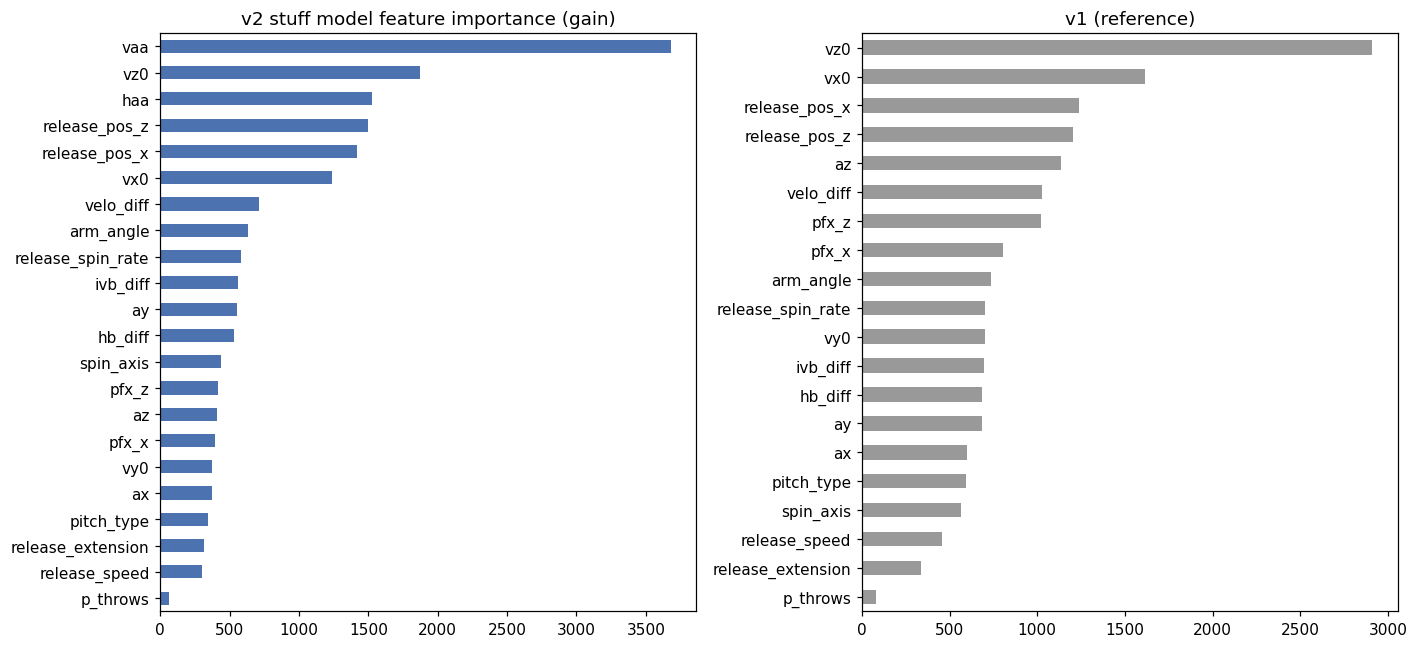

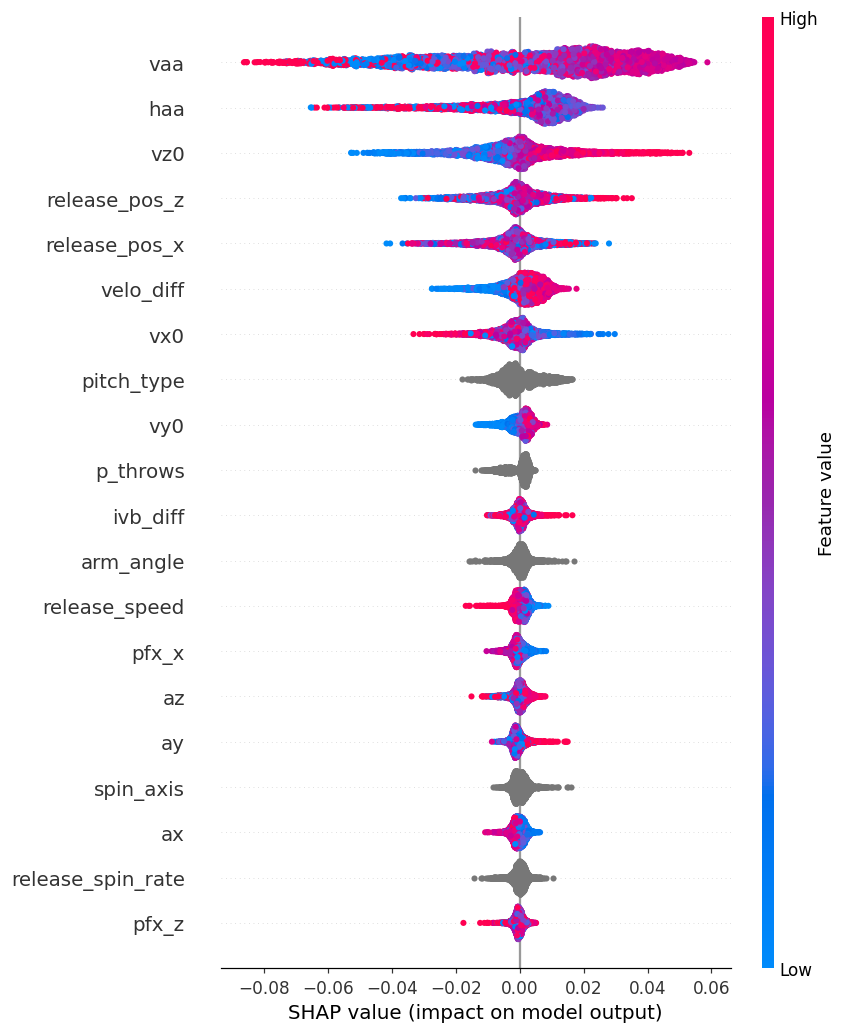

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
pd.Series(stuff_model.booster_.feature_importance('gain'), index=sp.STUFF_FEATURES_V2).sort_values() \
  .plot.barh(ax=axes[0], color='#4C72B0')
axes[0].set(title='v2 stuff model feature importance (gain)')
pd.Series(model_v1.booster_.feature_importance('gain'), index=sp.STUFF_FEATURES).sort_values() \
  .plot.barh(ax=axes[1], color='#999999')
axes[1].set(title='v1 (reference)')
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'stage3_importance.png')); plt.show()

import shap
X_shap = X3_va.sample(5000, random_state=SEED)
shap.summary_plot(shap.TreeExplainer(stuff_model).shap_values(X_shap), X_shap, show=False)
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'stage3_shap.png')); plt.show()

## 4. 최종 구위 score (20~80) — Waste 볼 점수 제외
- **Waste 볼** = 볼 판정(`ball`, `blocked_ball`) **이면서** Savant Waste 존 : 존 중심에서 좌우 20인치(|plate_x| > 1.67ft) 바깥, 또는 타자 존 높이 정규화(1.5~3.5ft) 기준 위아래 10인치 바깥
- 구위 모델은 로케이션을 보지 않으므로, 손에서 빠진 공이라도 물리량이 좋으면 점수가 높게 나온다 → 이런 공은 점수를 매기지 않는다 (투구 분포도에는 표시)
- 스케일러는 학습기간 투구 중 **점수를 매기는 투구(waste 볼 제외)** 로 적합 → 점수 대상 투구 기준 중앙값 50

waste 볼 : 77,876구 (11.0%), 볼 판정 중 30.8%
v2 train : median=50.00, mean=50.00, skew=0.000
v2 valid : median=50.07, mean=50.18

waste 볼의 v1 기존 점수 vs 나머지 투구 (기존 웹에서 waste 볼이 높게 나오던 현상 확인)


,count,mean,std,min,25%,50%,75%,max
waste,,,,,,,,
False,630717.0,48.46,8.97,20.0,42.47,48.79,54.79,80.0
True,77876.0,62.93,7.99,20.0,58.53,63.42,68.15,80.0


,n,waste,v1,v2
pitch_type,,,,
FO,540,0.248,57.090,56.377
FS,23580,0.181,54.145,54.450
CH,73088,0.16,52.977,53.322
SL,104854,0.135,52.435,52.926
ST,49997,0.143,52.209,52.154
KC,12016,0.18,52.244,51.293
SC,7,0.143,49.282,50.867
FC,53670,0.083,49.126,50.496
SV,3524,0.157,51.539,50.362


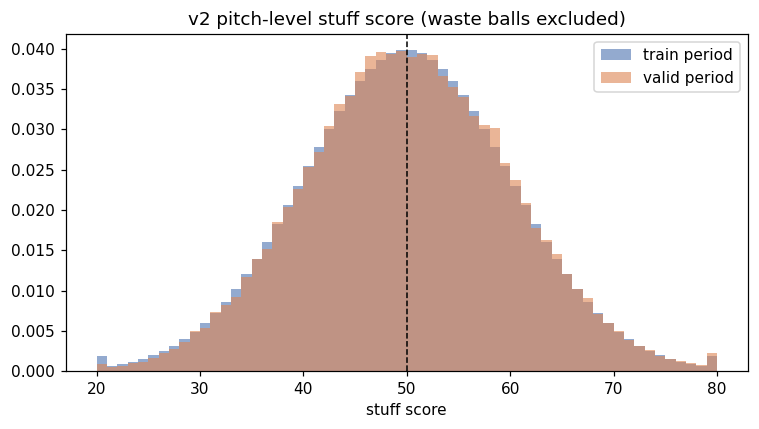

In [9]:
feat['waste'] = sp.is_waste_ball(feat)
feat['pred_v2'] = stuff_model.predict(feat[sp.STUFF_FEATURES_V2])
feat['pred_v1'] = model_v1.predict(feat[sp.STUFF_FEATURES])
is_train_pitch = feat['game_date'] < valid_start
scored = ~feat['waste']
print(f"waste 볼 : {feat['waste'].sum():,}구 ({feat['waste'].mean():.1%}), 볼 판정 중 {feat['waste'].sum() / feat['description'].isin(sp.BALL_DESC).sum():.1%}")

scaler = sp.StuffScaler().fit(feat.loc[is_train_pitch & scored, 'pred_v2'])
scaler_v1_ref = sp.StuffScaler().fit(feat.loc[is_train_pitch & scored, 'pred_v1'])    # 비교용 : v1 도 같은 대상 집합으로 재적합
feat['stuff_v2'] = pd.Series(scaler.transform(feat['pred_v2']), index=feat.index).where(scored)
feat['stuff_v1r'] = pd.Series(scaler_v1_ref.transform(feat['pred_v1']), index=feat.index).where(scored)
feat['stuff_v1'] = pd.Series(scaler_v1.transform(feat['pred_v1']), index=feat.index).where(scored)    # 기존 웹 점수 + waste 제외
feat['stuff_v1_all'] = scaler_v1.transform(feat['pred_v1'])                                           # 기존 웹 점수 그대로

s_tr = feat.loc[is_train_pitch, 'stuff_v2'].dropna()
print(f'v2 train : median={s_tr.median():.2f}, mean={s_tr.mean():.2f}, skew={stats.skew(s_tr):.3f}')
s_va = feat.loc[~is_train_pitch, 'stuff_v2'].dropna()
print(f'v2 valid : median={s_va.median():.2f}, mean={s_va.mean():.2f}')

print('\nwaste 볼의 v1 기존 점수 vs 나머지 투구 (기존 웹에서 waste 볼이 높게 나오던 현상 확인)')
display(feat.groupby('waste')['stuff_v1_all'].describe().round(2))
display(feat.groupby('pitch_type', observed=True).agg(n=('stuff_v2', 'size'), waste=('waste', 'mean'),
        v1=('stuff_v1_all', 'mean'), v2=('stuff_v2', 'mean')).sort_values('v2', ascending=False).round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(s_tr, bins=60, alpha=.6, density=True, label='train period', color='#4C72B0')
ax.hist(s_va, bins=60, alpha=.6, density=True, label='valid period', color='#DD8452')
ax.axvline(50, color='k', ls='--', lw=1)
ax.set(title='v2 pitch-level stuff score (waste balls excluded)', xlabel='stuff score'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'stage4_stuff_score.png')); plt.show()

## 5. v1 vs v2 비교
지표 정의는 모두 동일. 점수 열
- `v1_all` : 기존 웹 점수 그대로 (waste 볼 포함)
- `v1` : 기존 v1 점수에서 waste 볼만 제외
- `v1r` : v1 모델 + waste 제외 집합으로 스케일러 재적합 (v2 와 스케일 조건 동일 → **순수 모델 차이 비교용**)
- `v2` : 새 모델

### 5-1. 검증기간 타당성 (투수×구종 100구+, 투수 300구+)

In [10]:
SCORE_COLS = {'v1_all': 'stuff_v1_all', 'v1': 'stuff_v1', 'v1r': 'stuff_v1r', 'v2': 'stuff_v2'}

def validity(d):
    d = d.assign(swing=d['description'].isin(ew.SWING_DESC), whiff=d['description'].isin(sp.WHIFF_DESC),
                 xwoba_con=d['estimated_woba_using_speedangle'].where(d['type'] == 'X'))
    out = {}
    for name, col in SCORE_COLS.items():
        pp = (d.groupby(['pitcher', 'pitch_type'], observed=True)
                .agg(n=('swing', 'size'), stuff=(col, 'mean'), sw=('swing', 'sum'), wh=('whiff', 'sum'),
                     xc=('xwoba_con', 'mean')).query('n >= 100'))
        pt = (d.groupby('pitcher').agg(n=('swing', 'size'), stuff=(col, 'mean'), sw=('swing', 'sum'),
                                        wh=('whiff', 'sum')).query('n >= 300'))
        out[name] = {
            '투수×구종 ρ(구위, whiff%)': stats.spearmanr(pp['stuff'], pp['wh'] / pp['sw']).statistic,
            '투수×구종 ρ(구위, xwOBAcon)': stats.spearmanr(pp['stuff'], pp['xc'], nan_policy='omit').statistic,
            '투수 ρ(구위, whiff%)': stats.spearmanr(pt['stuff'], pt['wh'] / pt['sw']).statistic,
        }
    return pd.DataFrame(out)

valid_cmp = validity(feat[~is_train_pitch])
display(valid_cmp.round(3))

,v1_all,v1,v1r,v2
"투수×구종 ρ(구위, whiff%)",0.713,0.665,0.674,0.738
"투수×구종 ρ(구위, xwOBAcon)",-0.271,-0.266,-0.263,-0.286
"투수 ρ(구위, whiff%)",0.591,0.583,0.585,0.590


### 5-2. Out-of-sample 시즌 (2024·2026) — 구위 구간별 결과, 연도 간 안정성
2025 학습 모델과 스케일러를 그대로 적용. 구간별 피안타율·Whiff% 는 `export_web_data` 의 정의를 그대로 사용

In [11]:
cats = stuff_model.booster_.pandas_categorical

def score_oos(path, year):
    raw = sp.load_regular_season(path, year=year)
    d = sp.add_stuff_features(raw)
    for col, c in zip(sp.STUFF_CAT_FEATURES, cats):
        d[col] = pd.Categorical(d[col].astype(str), categories=c)
    d = d[d['pitch_type'].notna()]
    d['waste'] = sp.is_waste_ball(d)
    pv1, pv2 = model_v1.predict(d[sp.STUFF_FEATURES]), stuff_model.predict(d[sp.STUFF_FEATURES_V2])
    d['stuff_v1_all'] = scaler_v1.transform(pv1)
    d['stuff_v1'] = d['stuff_v1_all'].where(~d['waste'])
    d['stuff_v1r'] = pd.Series(scaler_v1_ref.transform(pv1), index=d.index).where(~d['waste'])
    d['stuff_v2'] = pd.Series(scaler.transform(pv2), index=d.index).where(~d['waste'])
    for col in sp.STUFF_CAT_FEATURES:
        d[col] = d[col].astype(str)
    d = ew.add_web_columns(raw, d)
    keep = ['pitcher', 'pitch_type', 'game_date', 'description', 'type', 'estimated_woba_using_speedangle',
            'pa_event', 'is_swing', 'is_whiff', 'result', 'xwoba', 'waste'] + list(SCORE_COLS.values())
    return d[keep]

def buckets(d, col):
    bins = pd.cut(d[col], ew.STUFF_BINS, labels=ew.STUFF_BIN_LABELS, right=False)
    rows = {lab: ew.outcome_rates(d[bins == lab]) for lab in ew.STUFF_BIN_LABELS}
    return pd.DataFrame(rows).T[['n', 'ba', 'whiff', 'xwobacon']]

f25 = feat.assign(pitch_type=feat['pitch_type'].astype(str))
seasons = {2025: f25[['pitcher', 'pitch_type', 'game_date', 'description', 'type', 'estimated_woba_using_speedangle',
                      'waste'] + list(SCORE_COLS.values())]}
for year, path in [(2024, 'games_24.pkl'), (2026, 'games_26.pkl')]:
    seasons[year] = score_oos(path, year)
    gc.collect()
    print(year, f'{len(seasons[year]):,}구, waste {seasons[year]["waste"].mean():.1%}')

oos_rows = []
for year in [2024, 2026]:
    for name, col in SCORE_COLS.items():
        b = buckets(seasons[year], col)
        oos_rows.append({'season': year, 'model': name,
                         'BA <40': b.loc['<40', 'ba'], 'BA 60+': b.loc['60+', 'ba'],
                         'BA 격차': b.loc['<40', 'ba'] - b.loc['60+', 'ba'],
                         'Whiff <40': b.loc['<40', 'whiff'], 'Whiff 60+': b.loc['60+', 'whiff'],
                         'Whiff 격차': b.loc['60+', 'whiff'] - b.loc['<40', 'whiff'],
                         'BA 단조': bool(b['ba'].is_monotonic_decreasing), 'Whiff 단조': bool(b['whiff'].is_monotonic_increasing),
                         'xwOBAcon 격차': b.loc['<40', 'xwobacon'] - b.loc['60+', 'xwobacon']})
oos_cmp = pd.DataFrame(oos_rows)
display(oos_cmp.round(3))
for year in [2024, 2026]:
    print(year, 'v2 구간별'); display(buckets(seasons[year], 'stuff_v2').round(3))

2024 708,479구, waste 11.6%
2026 713,177구, waste 14.0%


,season,model,BA <40,BA 60+,BA 격차,Whiff <40,Whiff 60+,Whiff 격차,BA 단조,Whiff 단조,xwOBAcon 격차
0,2024,v1_all,0.322,0.056,0.266,0.089,0.705,0.616,True,True,0.160
1,2024,v1,0.322,0.056,0.266,0.089,0.705,0.616,True,True,0.160
2,2024,v1r,0.324,0.081,0.243,0.088,0.612,0.525,True,True,0.153
3,2024,v2,0.320,0.082,0.238,0.080,0.627,0.547,True,True,0.155
4,2026,v1_all,0.323,0.052,0.270,0.085,0.702,0.618,True,True,0.161
5,2026,v1,0.323,0.052,0.270,0.085,0.702,0.618,True,True,0.161
6,2026,v1r,0.324,0.080,0.244,0.083,0.610,0.527,True,True,0.142
7,2026,v2,0.315,0.075,0.240,0.076,0.626,0.550,True,True,0.146


2024 v2 구간별


,n,ba,whiff,xwobacon
<40,99214.0,0.320,0.080,0.428
40-45,94870.0,0.294,0.106,0.393
45-50,120970.0,0.257,0.152,0.355
50-55,120751.0,0.228,0.231,0.324
55-60,93467.0,0.169,0.353,0.289
60+,96728.0,0.082,0.627,0.273


2026 v2 구간별


,n,ba,whiff,xwobacon
<40,97750.0,0.315,0.076,0.418
40-45,99986.0,0.292,0.106,0.390
45-50,126761.0,0.263,0.148,0.350
50-55,120969.0,0.228,0.228,0.320
55-60,90592.0,0.174,0.355,0.296
60+,77585.0,0.075,0.626,0.272


In [12]:
def pt_means(d, col, min_n=100):
    g = d.groupby(['pitcher', 'pitch_type'])[col].agg(['mean', 'count'])
    return g[g['count'] >= min_n]['mean']

def pt_whiff(d, min_n=100):
    g = d.assign(sw=d['description'].isin(ew.SWING_DESC), wh=d['description'].isin(sp.WHIFF_DESC)) \
         .groupby(['pitcher', 'pitch_type']).agg(n=('sw', 'size'), sw=('sw', 'sum'), wh=('wh', 'sum'))
    g = g[g['n'] >= min_n]
    return g['wh'] / g['sw']

stab_rows = {}
for name, col in SCORE_COLS.items():
    r = {}
    for a, b in [(2024, 2025), (2025, 2026)]:
        m = pd.concat([pt_means(seasons[a], col), pt_means(seasons[b], col)], axis=1, join='inner')
        r[f'안정성 r(구위 {a}, 구위 {b})'] = m.corr().iloc[0, 1]
        w = pd.concat([pt_means(seasons[a], col), pt_whiff(seasons[b])], axis=1, join='inner')
        r[f'예측력 ρ(구위 {a}, whiff% {b})'] = stats.spearmanr(w.iloc[:, 0], w.iloc[:, 1]).statistic
    stab_rows[name] = r
stab_cmp = pd.DataFrame(stab_rows)
display(stab_cmp.round(3))

,v1_all,v1,v1r,v2
"안정성 r(구위 2024, 구위 2025)",0.866,0.857,0.858,0.882
"예측력 ρ(구위 2024, whiff% 2025)",0.700,0.639,0.648,0.692
"안정성 r(구위 2025, 구위 2026)",0.852,0.838,0.838,0.862
"예측력 ρ(구위 2025, whiff% 2026)",0.707,0.641,0.649,0.695


### 5-3. 종합

In [13]:
comparison = pd.concat([
    metrics3.loc[['v1 LGBM (공통 표본)', 'v2 LGBM (공통 표본)']].rename(index={'v1 LGBM (공통 표본)': 'v1r', 'v2 LGBM (공통 표본)': 'v2'}).T
        .rename(index=lambda s: f'검증 {s} (공통 표본)'),
    valid_cmp[['v1r', 'v2']].rename(index=lambda s: f'검증 {s}'),
    oos_cmp.set_index(['season', 'model'])[['BA 격차', 'Whiff 격차', 'xwOBAcon 격차']].stack()
        .unstack('model')[['v1r', 'v2']].rename(index=lambda s: str(s)).pipe(lambda x: x.set_axis([f'{a} {b}' for a, b in x.index])),
    stab_cmp[['v1r', 'v2']],
])
comparison['v2 - v1r'] = comparison['v2'] - comparison['v1r']
display(comparison.round(4))
comparison.to_csv(os.path.join(OUT, 'model_comparison.csv'), encoding='utf-8-sig')
pd.concat({'valid': valid_cmp, 'stability': stab_cmp}).to_csv(os.path.join(OUT, 'model_comparison_all_scores.csv'), encoding='utf-8-sig')
oos_cmp.to_csv(os.path.join(OUT, 'oos_bucket_comparison.csv'), index=False, encoding='utf-8-sig')

,v1r,v2,v2 - v1r
검증 RMSE (공통 표본),0.1630,0.1622,-0.0009
검증 MAE (공통 표본),0.1127,0.1131,0.0004
검증 R2 (공통 표본),0.0816,0.0912,0.0096
"검증 투수×구종 ρ(구위, whiff%)",0.6744,0.7383,0.0639
"검증 투수×구종 ρ(구위, xwOBAcon)",-0.2635,-0.2860,-0.0225
"검증 투수 ρ(구위, whiff%)",0.5850,0.5904,0.0054
2024 BA 격차,0.2427,0.2377,-0.0050
2024 Whiff 격차,0.5250,0.5469,0.0220
2024 xwOBAcon 격차,0.1530,0.1549,0.0019
2026 BA 격차,0.2438,0.2405,-0.0034


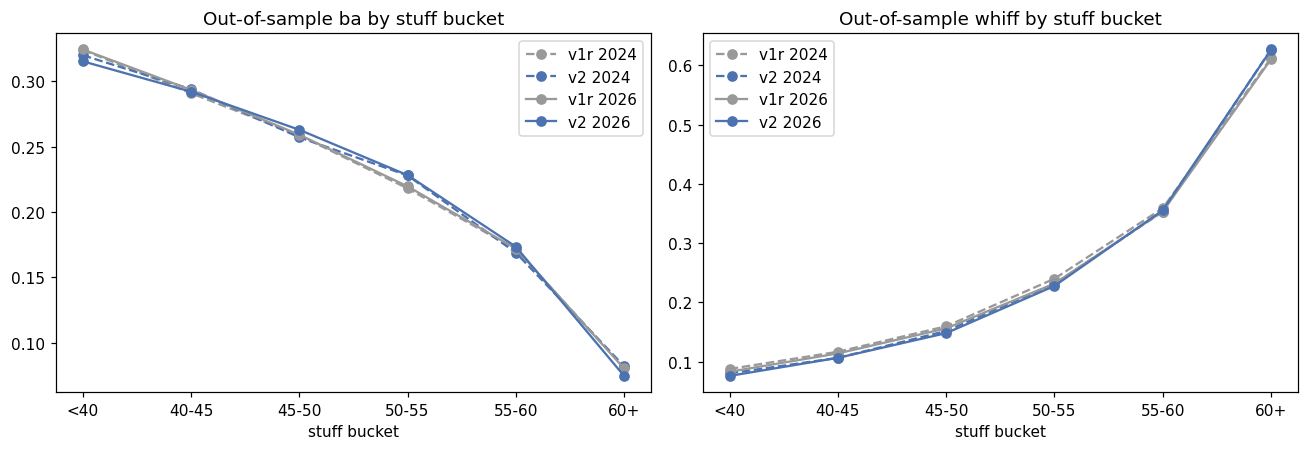

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, metric in zip(axes, ['ba', 'whiff']):
    for year, ls in [(2024, '--'), (2026, '-')]:
        for name, color in [('v1r', '#999999'), ('v2', '#4C72B0')]:
            b = buckets(seasons[year], SCORE_COLS[name])
            ax.plot(ew.STUFF_BIN_LABELS, b[metric], ls=ls, marker='o', color=color, label=f'{name} {year}')
    ax.set(title=f'Out-of-sample {metric} by stuff bucket', xlabel='stuff bucket'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'compare_oos_buckets.png')); plt.show()

### 5-4. 판정 : **v2 를 웹 모델로 채택**
순수 모델 비교(`v1r` vs `v2`, 동일 waste 제외·동일 스케일 조건)에서 v2 가 대부분 우세
- 검증기간 타당성 : 투수×구종 ρ(구위, whiff%) 0.674 → **0.738**, ρ(구위, xwOBAcon) −0.264 → **−0.286**, 투수 단위 0.585 → 0.590
- 연도 간 안정성(투수×구종) : 2024→25 0.858 → **0.882**, 2025→26 0.838 → **0.862**
- 다음 시즌 whiff% 예측력 : 0.648 → **0.692**, 0.649 → **0.695**
- OOS 구간 격차 : Whiff 격차 +0.02 (2024·2026 모두), xwOBAcon 격차 소폭 개선, BA 격차는 −0.004 수준으로 비슷. 구간 단조성은 두 모델 모두 유지
- 공통 표본 RMSE 0.1630 → 0.1622, R² 0.082 → 0.091 (MAE 는 0.0004 소폭 악화)

해석 메모
- `v1_all`(기존 웹 점수, waste 볼 포함)의 예측력 ρ 가 0.70 으로 높게 보이는 것은, 원바운드 볼이 많은 투수(주로 변화구 위주 = whiff 높은 투수)의 점수가 waste 볼 덕분에 올라간 효과가 섞인 것. waste 볼의 v1 평균 점수는 62.9 로 나머지(48.5)보다 크게 높았다 → 사용자가 지적한 현상 확인
- v2 의 VAA 는 원값이라 plate_z 와 상관 0.75 → 높이 정보가 일부 반영됨. 개선분 일부가 로케이션 효과일 수 있음 (추후 높이 보정 VAA 와 비교 검토)


## 6. 산출물 저장 (v2 전용 경로)

In [15]:
joblib.dump(stuff_model, os.path.join('models', 'v2', 'stage3_stuff_lgbm.joblib'))
joblib.dump(scaler, os.path.join('models', 'v2', 'stage4_stuff_scaler.joblib'), compress=3)
cols = ['game_date', 'game_pk', 'at_bat_number', 'pitch_number', 'pitcher', 'player_name', 'pitch_type',
        'description', 'events', 'vaa', 'haa', 'waste', 'pred_v2', 'stuff_v2']
(feat[cols].rename(columns={'pred_v2': 'pred_hit_quality', 'stuff_v2': 'stuff_score'})
     .assign(pitch_type=feat['pitch_type'].astype(str))
     .to_parquet(os.path.join(OUT, 'stuff_scores_2025.parquet'), index=False))
metrics3.to_csv(os.path.join(OUT, 'stage3_metrics.csv'), encoding='utf-8-sig')
print('saved')

saved
